In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

import librosa
import librosa.display

In [2]:
dataset_path = "archive/Audio_Speech_Actors_01-24"

In [3]:
audio_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("Total files:", len(audio_files))
print(audio_files[0])

Total files: 1440
archive/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav


In [4]:
audio_path = audio_files[0]

audio, sr = librosa.load(audio_path, sr=None)

duration = len(audio) / sr

print("Sample Rate :", sr)
print("Duration :", duration, "seconds")

Sample Rate : 48000
Duration : 3.3032916666666665 seconds


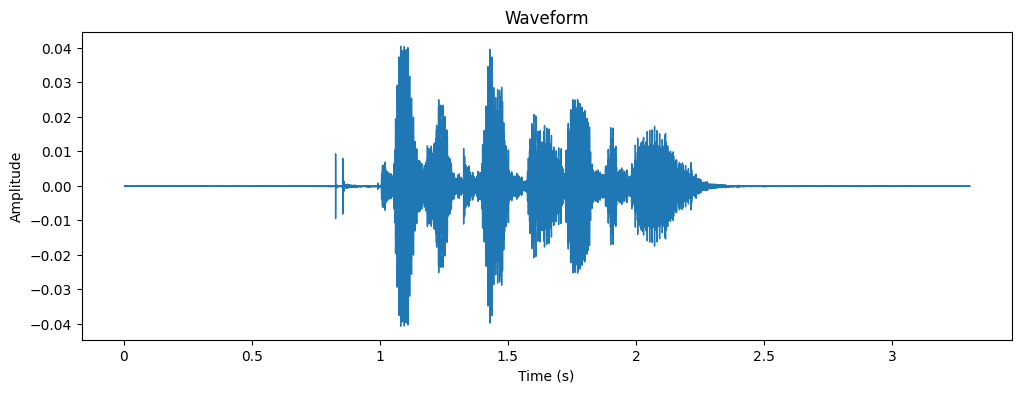

In [5]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(audio, sr=sr)

plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.show()

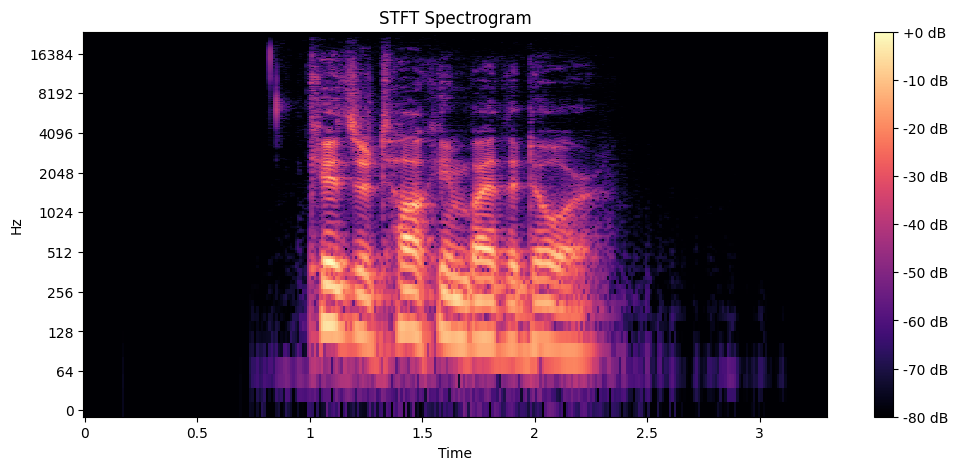

In [6]:
D = librosa.amplitude_to_db(
    np.abs(librosa.stft(audio)),
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    D,
    sr=sr,
    x_axis='time',
    y_axis='log'
)

plt.colorbar(format='%+2.0f dB')

plt.title("STFT Spectrogram")

plt.show()

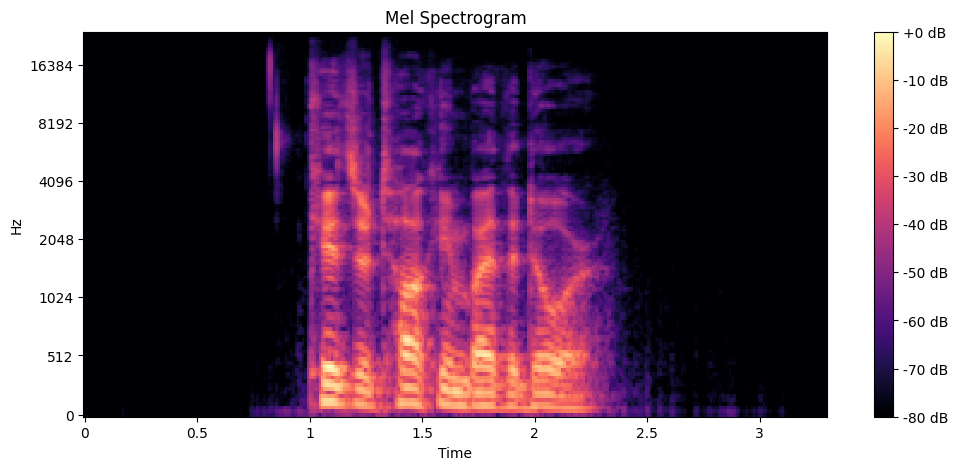

In [104]:
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')

plt.title("Mel Spectrogram")

plt.show()

In [109]:
# We opted for n_fft equal to 2048 for proper frequency resolution of speech analysis along with good temporal data. The following hop_length of 512 offers overlapping analysis windows providing smoother spectrograms. The number of mel filter banks is 128 as the mel filter scale approximates human hearing most accurately thus providing a compact representation of the speech.

In [105]:
os.makedirs("charts", exist_ok=True)

In [106]:
plt.savefig("charts/waveform.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [107]:
plt.savefig("charts/stft.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [108]:
plt.savefig("charts/mel.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [12]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [13]:
def get_emotion(file_path):

    filename = os.path.basename(file_path)

    emotion_code = filename.split("-")[2]

    return emotion_map[emotion_code]

In [14]:
print(audio_files[0])
print(get_emotion(audio_files[0]))

archive/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav
neutral


In [15]:
def extract_mfcc(file_path, n_mfcc=40):

    audio, sr = librosa.load(file_path, sr=16000)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc
    )

    # Average across time
    mfcc = np.mean(mfcc, axis=1)

    return mfcc

In [16]:
mfcc = extract_mfcc(audio_files[0])

print(mfcc.shape)

(40,)


In [17]:
X = []
y = []

for file in audio_files:

    X.append(extract_mfcc(file))

    y.append(get_emotion(file))

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(1440, 40)
(1440,)


In [18]:
import pandas as pd

pd.Series(y).value_counts()

calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def train_and_evaluate(X, y, model_name):

    X = np.array(X)
    y = np.array(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        random_state=42
    )

    skf = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    uar_scores = []

    y_true = []
    y_pred = []

    for train_index, test_index in skf.split(X_scaled, y):

        X_train = X_scaled[train_index]
        X_test = X_scaled[test_index]

        y_train = y[train_index]
        y_test = y[test_index]

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        uar = recall_score(
            y_test,
            predictions,
            average="macro"
        )

        uar_scores.append(uar)

        y_true.extend(y_test)
        y_pred.extend(predictions)

    print(f"\n===== {model_name} =====")
    print(f"Average UAR : {np.mean(uar_scores):.4f}")
    print(f"Std Dev     : {np.std(uar_scores):.4f}")

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    fig, ax = plt.subplots(figsize=(8,8))

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return model, scaler, np.mean(uar_scores)

Training MFCC + SVM

===== MFCC + SVM =====
Average UAR : 0.5410
Std Dev     : 0.0338


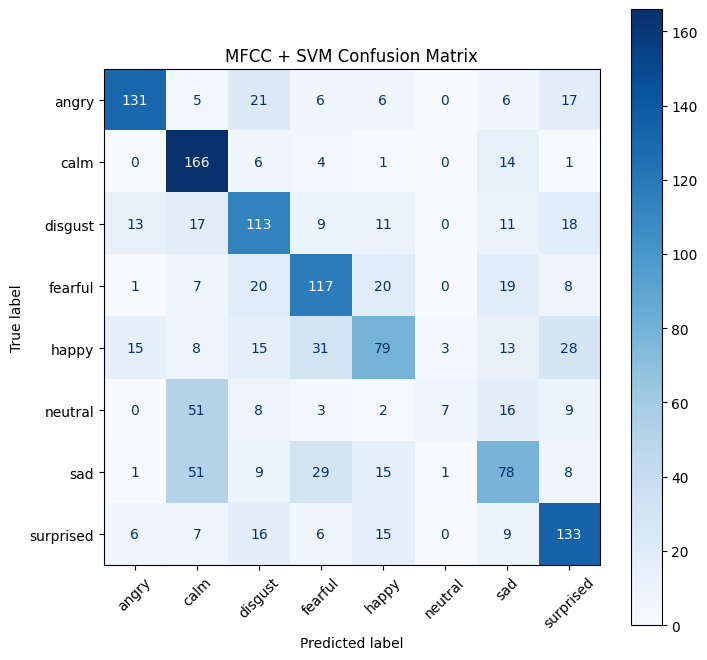

In [20]:
print("="*60)
print("Training MFCC + SVM")
print("="*60)

mfcc_model, mfcc_scaler, mfcc_uar = train_and_evaluate(
    X,
    y,
    "MFCC + SVM"
)

In [21]:
import opensmile

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals
)

In [22]:
from tqdm import tqdm
import time

print("="*60)
print("Extracting eGeMAPS Features")
print("="*60)

start = time.time()

X_egemaps = []
y_egemaps = []

for file in tqdm(audio_files):

    features = smile.process_file(file)

    X_egemaps.append(features.iloc[0].values)

    y_egemaps.append(get_emotion(file))

print(f"\nFinished in {time.time()-start:.2f} seconds")

Extracting eGeMAPS Features


100%|██████████████████████████████████████████████████████████████████████████████| 1440/1440 [03:29<00:00,  6.87it/s]


Finished in 209.65 seconds


In [23]:
X_egemaps = np.array(X_egemaps)
y_egemaps = np.array(y_egemaps)

print("eGeMAPS Shape:", X_egemaps.shape)
print("Labels:", y_egemaps.shape)

eGeMAPS Shape: (1440, 88)
Labels: (1440,)


Training eGeMAPS + SVM

===== eGeMAPS + SVM =====
Average UAR : 0.5820
Std Dev     : 0.0367


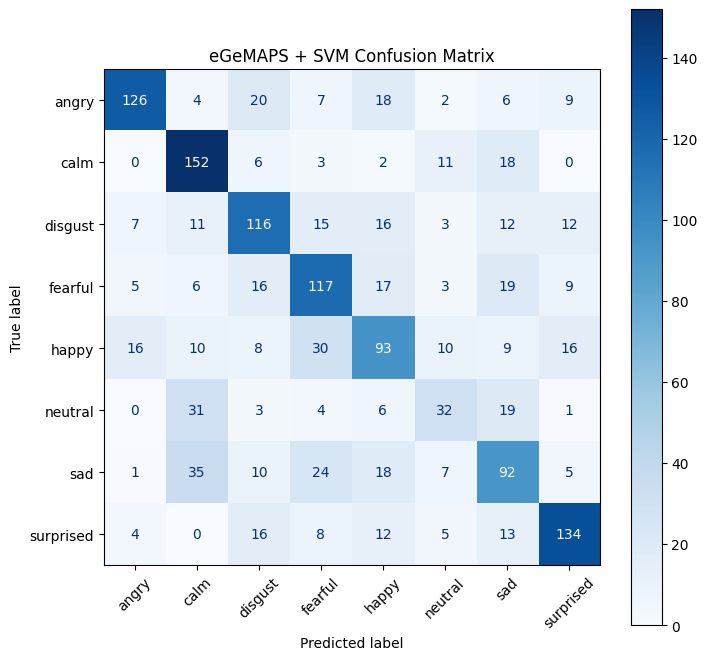

In [24]:
print("="*60)
print("Training eGeMAPS + SVM")
print("="*60)

egemaps_model, egemaps_scaler, egemaps_uar = train_and_evaluate(
    X_egemaps,
    y_egemaps,
    "eGeMAPS + SVM"
)

In [25]:
comparison = pd.DataFrame({
    "Feature": ["MFCC", "eGeMAPS"],
    "UAR": [mfcc_uar, egemaps_uar]
})

comparison

,Feature,UAR
0,MFCC,0.541049
1,eGeMAPS,0.582010


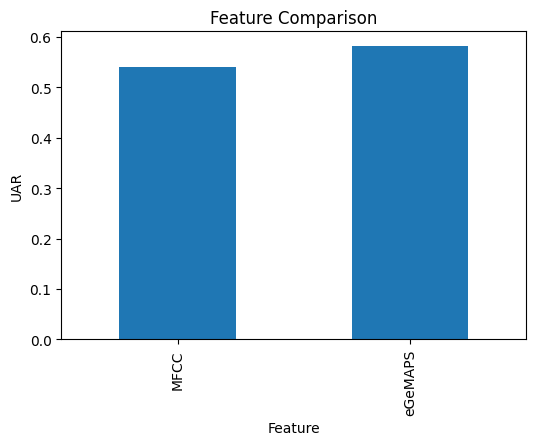

In [26]:
comparison.plot(
    x="Feature",
    y="UAR",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylabel("UAR")
plt.title("Feature Comparison")

plt.show()

In [37]:
from transformers import (
    Wav2Vec2Model,
    Wav2Vec2FeatureExtractor
)

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score

import torch
from tqdm import tqdm
import time

In [38]:
print("="*60)
print("Loading Wav2Vec2 Model...")
print("="*60)

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    "facebook/wav2vec2-base"
)

wav2vec_model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base"
)

wav2vec_model.eval()

print("Model Loaded Successfully!")

Loading Wav2Vec2 Model...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model Loaded Successfully!


In [39]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

wav2vec_model.to(device)

print("Running on:", device)

Running on: cpu


In [40]:
def extract_embedding(file_path, layer=-1):

    audio, sr = librosa.load(
        file_path,
        sr=16000
    )

    inputs = feature_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = wav2vec_model(
            **inputs,
            output_hidden_states=True
        )

    hidden = outputs.hidden_states[layer]

    embedding = hidden.mean(dim=1)

    return embedding.squeeze().cpu().numpy()

In [41]:
embedding = extract_embedding(audio_files[0])

print(embedding.shape)

(768,)


In [42]:
print("="*60)
print("Extracting Wav2Vec2 Embeddings")
print("="*60)

start = time.time()

X_wav2vec = []
y_wav2vec = []

for i, file in enumerate(tqdm(audio_files), start=1):

    X_wav2vec.append(extract_embedding(file))
    y_wav2vec.append(get_emotion(file))

    if i % 100 == 0:
        print(f"\nCompleted {i}/{len(audio_files)} files")

X_wav2vec = np.array(X_wav2vec)
y_wav2vec = np.array(y_wav2vec)

print("\nFinished!")
print("Shape:", X_wav2vec.shape)
print(f"Time: {(time.time()-start)/60:.2f} minutes")

Extracting Wav2Vec2 Embeddings


  7%|█████▍                                                                         | 100/1440 [00:26<05:49,  3.83it/s]


Completed 100/1440 files


 14%|██████████▉                                                                    | 200/1440 [00:52<05:17,  3.91it/s]


Completed 200/1440 files


...


Completed 1300/1440 files


 97%|███████████████████████████████████████████████████████████████████████████▊  | 1400/1440 [06:03<00:10,  3.72it/s]


Completed 1400/1440 files


100%|██████████████████████████████████████████████████████████████████████████████| 1440/1440 [06:14<00:00,  3.84it/s]


Finished!
Shape: (1440, 768)
Time: 6.24 minutes


In [43]:
print("="*60)
print("Training Linear Probe")
print("="*60)

linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(random_state=42))
])

predictions = cross_val_predict(
    linear_pipeline,
    X_wav2vec,
    y_wav2vec,
    cv=10,
    n_jobs=-1
)

wav2vec_uar = recall_score(
    y_wav2vec,
    predictions,
    average="macro"
)

print(f"Wav2Vec2 + LinearSVC UAR: {wav2vec_uar:.4f}")

Training Linear Probe
Wav2Vec2 + LinearSVC UAR: 0.5684


In [44]:
comparison_m2 = pd.DataFrame({
    "Model": [
        "MFCC + SVM",
        "eGeMAPS + SVM",
        "Wav2Vec2 + LinearSVC"
    ],
    "UAR": [
        mfcc_uar,
        egemaps_uar,
        wav2vec_uar
    ]
})

comparison_m2

,Model,UAR
0,MFCC + SVM,0.541049
1,eGeMAPS + SVM,0.582010
2,Wav2Vec2 + LinearSVC,0.568359


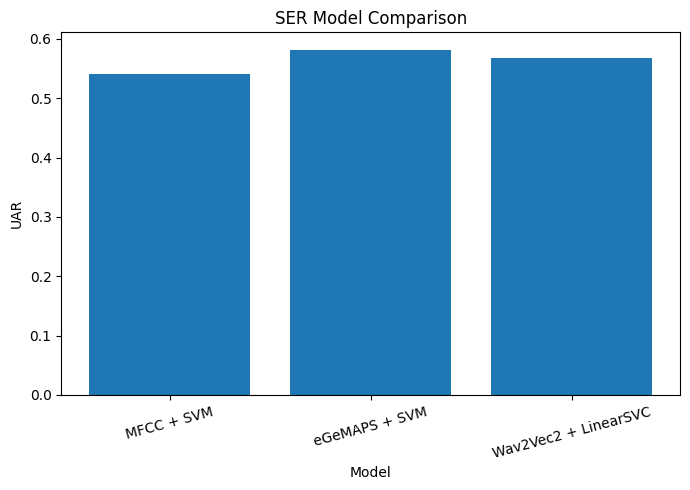

In [45]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison_m2["Model"],
    comparison_m2["UAR"]
)

plt.ylabel("UAR")
plt.xlabel("Model")
plt.title("SER Model Comparison")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

In [46]:
probe_layers = [1, 4, 8, 12]

layer_results = []

In [47]:
for layer in probe_layers:

    print("="*60)
    print(f"Processing Layer {layer}")
    print("="*60)

    X_layer = []

    for file in tqdm(audio_files):

        X_layer.append(
            extract_embedding(
                file,
                layer=layer
            )
        )

    X_layer = np.array(X_layer)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LinearSVC(random_state=42))
    ])

    predictions = cross_val_predict(
        pipeline,
        X_layer,
        y,
        cv=10,
        n_jobs=-1
    )

    uar = recall_score(
        y,
        predictions,
        average="macro"
    )

    layer_results.append(uar)

    print(f"Layer {layer} UAR = {uar:.4f}")

Processing Layer 1


100%|██████████████████████████████████████████████████████████████████████████████| 1440/1440 [06:27<00:00,  3.72it/s]


Layer 1 UAR = 0.6387
Processing Layer 4


100%|██████████████████████████████████████████████████████████████████████████████| 1440/1440 [06:39<00:00,  3.60it/s]


Layer 4 UAR = 0.6940
Processing Layer 8


100%|██████████████████████████████████████████████████████████████████████████████| 1440/1440 [06:11<00:00,  3.88it/s]


Layer 8 UAR = 0.6999
Processing Layer 12


100%|██████████████████████████████████████████████████████████████████████████████| 1440/1440 [06:12<00:00,  3.87it/s]


Layer 12 UAR = 0.5684


In [48]:
layer_df = pd.DataFrame({
    "Layer": probe_layers,
    "UAR": layer_results
})

layer_df

,Layer,UAR
0,1,0.638672
1,4,0.694010
2,8,0.699870
3,12,0.568359


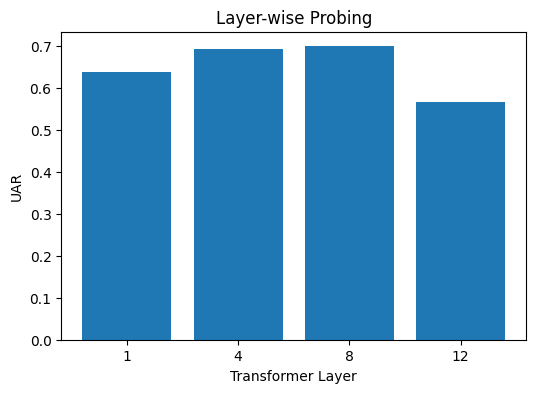

In [49]:
plt.figure(figsize=(6,4))

plt.bar(
    layer_df["Layer"].astype(str),
    layer_df["UAR"]
)

plt.xlabel("Transformer Layer")
plt.ylabel("UAR")
plt.title("Layer-wise Probing")

plt.show()

In [50]:
best_idx = np.argmax(layer_results)

print("="*60)
print("Best Layer")
print("="*60)

print(f"Best Layer : {probe_layers[best_idx]}")
print(f"Best UAR   : {layer_results[best_idx]:.4f}")

Best Layer
Best Layer : 8
Best UAR   : 0.6999


In [33]:
from transformers import (
    Wav2Vec2ForCTC,
    Wav2Vec2Processor
)

import torch
import time

In [34]:
print("="*60)
print("Loading Wav2Vec2 ASR Model")
print("="*60)

processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

asr_model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

asr_model.eval()

print("ASR model loaded successfully.")

Loading Wav2Vec2 ASR Model


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--facebook--wav2vec2-base-960h. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ASR model loaded successfully.


In [35]:
def transcribe_audio(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000
    )

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        logits = asr_model(**inputs).logits

    predicted_ids = torch.argmax(logits, dim=-1)

    transcript = processor.batch_decode(
        predicted_ids
    )[0]

    return transcript

In [36]:
start = time.time()

transcript = transcribe_audio(audio_files[0])

print("\nTranscript:")
print(transcript)

print(f"\nTime: {time.time()-start:.2f} sec")


Transcript:
KIDS ARE TALKING BY THE DOOR

Time: 0.42 sec


In [53]:
librispeech_path = "test-clean/LibriSpeech/test-clean"

In [54]:
print(os.path.exists(librispeech_path))
print(os.listdir(librispeech_path)[:5])

True
['1089', '1188', '121', '1221', '1284']


In [55]:
import glob

speech_files = sorted(
    glob.glob(os.path.join(librispeech_path, "**", "*.flac"), recursive=True)
)

transcript_files = sorted(
    glob.glob(os.path.join(librispeech_path, "**", "*.trans.txt"), recursive=True)
)

print("Audio files:", len(speech_files))
print("Transcript files:", len(transcript_files))

Audio files: 2620
Transcript files: 87


In [56]:
transcript_dict = {}

for file in transcript_files:

    with open(file, "r", encoding="utf-8") as f:

        for line in f:

            parts = line.strip().split(" ", 1)

            if len(parts) == 2:

                transcript_dict[parts[0]] = parts[1]

print("Total transcripts:", len(transcript_dict))

Total transcripts: 2620


In [57]:
first_audio = speech_files[0]

audio_id = os.path.splitext(
    os.path.basename(first_audio)
)[0]

print(audio_id)
print(transcript_dict[audio_id])

1089-134686-0000
HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOUR FATTENED SAUCE


In [60]:
from jiwer import wer, cer
from tqdm import tqdm

In [61]:
references = []
predictions = []

print("=" * 60)
print("Evaluating ASR")
print("=" * 60)

for i, audio_file in enumerate(tqdm(speech_files), start=1):

    audio_id = os.path.splitext(
        os.path.basename(audio_file)
    )[0]

    reference = transcript_dict[audio_id]

    prediction = transcribe_audio(audio_file)

    references.append(reference)
    predictions.append(prediction)

    if i % 100 == 0:
        print(f"Completed {i}/{len(speech_files)} files")

Evaluating ASR


  4%|███                                                                            | 100/2620 [01:04<28:36,  1.47it/s]

Completed 100/2620 files


  8%|██████                                                                         | 200/2620 [02:10<37:38,  1.07it/s]

Completed 200/2620 files


...

 95%|██████████████████████████████████████████████████████████████████████████▍   | 2500/2620 [21:45<00:59,  2.02it/s]

Completed 2500/2620 files


 99%|█████████████████████████████████████████████████████████████████████████████▍| 2600/2620 [22:42<00:10,  1.86it/s]

Completed 2600/2620 files


100%|██████████████████████████████████████████████████████████████████████████████| 2620/2620 [22:54<00:00,  1.91it/s]


In [71]:
import jiwer

wer_score = jiwer.wer(
    references,
    predictions,
    reference_transform=jiwer.wer_standardize,
    hypothesis_transform=jiwer.wer_standardize
)

cer_score = jiwer.cer(
    references,
    predictions,
    reference_transform=jiwer.wer_standardize,
    hypothesis_transform=jiwer.wer_standardize
)

print("="*60)
print("ASR Evaluation")
print("="*60)

print(f"WER : {wer_score:.4f}")
print(f"CER : {cer_score:.4f}")

ASR Evaluation
WER : 0.0337
CER : 0.0337


In [72]:
for i in range(10):

    print("=" * 60)
    print("Ground Truth:")
    print(references[i])

    print("\nPrediction:")
    print(predictions[i])

Ground Truth:
HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOUR FATTENED SAUCE

Prediction:
HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOWER FAT AND SAUCE
Ground Truth:
STUFF IT INTO YOU HIS BELLY COUNSELLED HIM

Prediction:
STUFFERED INTO YOU HIS BELLY COUNSELLED HIM
Ground Truth:
AFTER EARLY NIGHTFALL THE YELLOW LAMPS WOULD LIGHT UP HERE AND THERE THE SQUALID QUARTER OF THE BROTHELS

Prediction:
AFTER EARLY NIGHTFALL THE YELLOW LAMPS WOULD LIGHT UP HERE AND THERE THE SQUALID QUARTER OF THE BROTHELS
Ground Truth:
HELLO BERTIE ANY GOOD IN YOUR MIND

Prediction:
HO BERTIE ANY GOOD IN YOUR MIND
Ground Truth:
NUMBER TEN FRESH NELLY IS WAITING ON YOU GOOD NIGHT HUSBAND

Prediction:
NUMBER TEN FRESH NELLY IS WAITING ON YOU GOOD NIGHT HUSBAND
Ground Truth:
THE MUSIC CAME NEARER AND HE RECALLED THE WORDS T

In [77]:
import joblib

joblib.dump(egemaps_model, "ser_model.pkl")
joblib.dump(egemaps_scaler, "ser_scaler.pkl")

print("SER model and scaler saved successfully!")

SER model and scaler saved successfully!


In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import joblib

# Train on the complete eGeMAPS dataset
final_scaler = StandardScaler()
X_final = final_scaler.fit_transform(X_egemaps)

final_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True,
    random_state=42
)

final_model.fit(X_final, y_egemaps)

# Save model and scaler
joblib.dump(final_model, "ser_model.pkl")
joblib.dump(final_scaler, "ser_scaler.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [87]:
import joblib

ser_model = joblib.load("ser_model.pkl")
ser_scaler = joblib.load("ser_scaler.pkl")

In [95]:
features = smile.process_file(test_file)
X_test = features.to_numpy()
X_test = ser_scaler.transform(X_test)

prediction = ser_model.predict(X_test)[0]

probabilities = ser_model.predict_proba(X_test)[0]
confidence = probabilities.max()

print("True Emotion :", get_emotion(test_file))
print("Prediction   :", prediction)
print("Confidence   :", confidence)

True Emotion : calm
Prediction   : calm
Confidence   : 0.9398167391486391


In [96]:
import json
import time

test_file = audio_files[0]

start = time.time()

# ---------- SER ----------
features = smile.process_file(test_file)
X_test = features.to_numpy()
X_test = ser_scaler.transform(X_test)

emotion = ser_model.predict(X_test)[0]
confidence = float(ser_model.predict_proba(X_test)[0].max())

# ---------- ASR ----------
transcript = transcribe_audio(test_file)

# ---------- OUTPUT ----------
result = {
    "transcript": transcript,
    "emotion": {
        "label": emotion,
        "confidence": round(confidence, 4)
    },
    "asr_model": "facebook/wav2vec2-base-960h",
    "ser_model": "eGeMAPS + SVM",
    "processing_time_sec": round(time.time() - start, 2)
}

print(json.dumps(result, indent=4))

{
    "transcript": "KIDS ARE TALKING BY THE DOOR",
    "emotion": {
        "label": "neutral",
        "confidence": 0.3674
    },
    "asr_model": "facebook/wav2vec2-base-960h",
    "ser_model": "eGeMAPS + SVM",
    "processing_time_sec": 0.38
}


In [97]:
print(test_file)
print(get_emotion(test_file))

archive/Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav
neutral


In [98]:
test_file = audio_files[0]

features = smile.process_file(test_file)
X_test = features.to_numpy()
X_test = ser_scaler.transform(X_test)

prediction = ser_model.predict(X_test)[0]
confidence = ser_model.predict_proba(X_test)[0].max()

print("Prediction:", prediction)
print("Confidence:", confidence)

Prediction: neutral
Confidence: 0.3674305663838627


In [88]:
import joblib
import json

print("Loading SER model...")

ser_model = joblib.load("ser_model.pkl")
ser_scaler = joblib.load("ser_scaler.pkl")

print("SER model loaded successfully!")

Loading SER model...
SER model loaded successfully!


In [102]:
import sys
!{sys.executable} -m pip show joblib

Name: joblib
Version: 1.5.1
Summary: Lightweight pipelining with Python functions
Home-page: https://joblib.readthedocs.io
Author: 
Author-email: Gael Varoquaux <gael.varoquaux@normalesup.org>
License: BSD 3-Clause
Location: C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages
Requires: 
Required-by: imbalanced-learn, librosa, nltk, pynndescent, scikit-learn


In [103]:
import sys

!{sys.executable} voxsense.py --file "archive/Actor_01/03-01-01-01-01-01-01.wav"

Loading models...
Models loaded.
{
    "transcript": "KIDS ARE TALKING BY THE DOOR",
    "emotion": {
        "label": "neutral",
        "confidence": 0.3674
    },
    "asr_model": "facebook/wav2vec2-base-960h",
    "ser_model": "eGeMAPS + SVM",
    "processing_time_sec": 3.85
}



Loading weights: 100%|##########| 212/212 [00:00<00:00, 5168.19it/s]
[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
